# Layer 3 (PFF): RQ3 part 3, the answer to RQ3

**RQ3** asks whether blind passes (passes to a teammate outside the passer's vision cone) can be explained by spatial memory. Could the passer have known where the receiver was?

The proposal's headline outcome is **the proportion of blind passes that are memory-feasible**. A blind pass is memory-feasible when the LSTM, using only what the passer saw of the receiver in the previous 5 s, places the receiver within tau of their true position. tau = 4.66 m comes from defensive line widths (part 1), and the LSTM is cross-fitted (part 2).

This notebook reports:

1. the headline proportion, with the ablation over tau and the baselines the proposal compares against;
2. a within-pass test: are blind-pass receivers more often memory-feasible than the other unseen teammates the passer could have chosen?
3. whether a pass aimed at the remembered position would actually have arrived;
4. a side-by-side comparison with the StatsBomb version of RQ3.

Only receivers tracked on camera (VISIBLE) at the pass are scored, since their true position is measured rather than estimated. A receiver the passer did not see at all in the previous 5 s has no memory to draw on, and counts as not memory-feasible.

In [1]:
# shared figure settings used in every notebook:
# colours (navy, green, grey and light blue) and one folder for every saved figure
import matplotlib.pyplot as plt
from cycler import cycler
from pathlib import Path
plt.rcParams['axes.prop_cycle'] = cycler(color=['#1E2761', '#2C5F2D', '#9AA0A6', '#7F8FC0'])

FIGURES = Path('../data/results/figures')
FIGURES.mkdir(parents=True, exist_ok=True)


def save_fig(fig, name):
    """Save a figure to the shared figures folder, in the same format in every notebook."""
    fig.savefig(FIGURES / name, dpi=200, bbox_inches='tight', facecolor='white')
    print(f"saved {FIGURES / name}")


import sys, os, json, time
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.join('..', 'src'))
import importlib
import pff, pff_memory
importlib.reload(pff)
importlib.reload(pff_memory)

RESULTS = Path('../data/results')
ARR_DIR = Path('../data/pff_arrays')
TAU = json.load(open(RESULTS / 'pff_tau.json'))['tau_m']

mates = pd.read_pickle(RESULTS / 'pff_memory_mates.pkl')
preds = pd.read_pickle(RESULTS / 'pff_lstm_predictions.pkl').set_index('mate_row')
mates = mates.join(preds[['pred_last_x', 'pred_last_y', 'pred_cv_x', 'pred_cv_y', 'pred_lstm_x', 'pred_lstm_y',
                          'err_last', 'err_cv', 'err_lstm']])
mates['has_memory'] = mates['n_seen'].fillna(0) > 0
unseen = mates[~mates['in_cone']]
blind_all = unseen[unseen['is_receiver'] & unseen['complete']]
blind = blind_all[blind_all['target_visible']].copy()
print(f"tau = {TAU:.2f} m")
print(f"blind passes (completed, receiver outside the cone): {len(blind_all)}")
print(f"  with the receiver tracked on camera at the pass: {len(blind)} ({len(blind) / len(blind_all):.1%})")

tau = 4.66 m
blind passes (completed, receiver outside the cone): 22696
  with the receiver tracked on camera at the pass: 15101 (66.5%)


## 1. The headline: how many blind passes are memory-feasible?

The table gives the share of blind passes whose receiver is placed within tau by each method. For each tau it shows the share placed within that distance; a receiver with no seen history counts as not feasible.

In [2]:
blind['feasible_lstm'] = blind['has_memory'] & (blind['err_lstm'] < TAU)
print(f"receiver seen by the passer in the previous 5 s: {blind['has_memory'].mean():.1%}")
print(f"MEMORY-FEASIBLE BLIND PASSES (LSTM, tau = {TAU:.2f} m): {blind['feasible_lstm'].mean():.1%} "
      f"({blind['feasible_lstm'].sum()} of {len(blind)})")
print(f"  as a share of blind passes whose receiver was seen: {blind.loc[blind['has_memory'], 'feasible_lstm'].mean():.1%}")


def game_ci(df, col, n_boot=5000, seed=0):
    g = df.groupby('pff_game_id')[col].agg(['sum', 'size'])
    idx = np.random.default_rng(seed).integers(0, len(g), size=(n_boot, len(g)))
    r = g['sum'].to_numpy()[idx].sum(1) / g['size'].to_numpy()[idx].sum(1)
    return np.percentile(r, [2.5, 97.5])


lo, hi = game_ci(blind, 'feasible_lstm')
print(f"  95% CI (resampling games): {lo:.1%} to {hi:.1%}")

print()
print('ablation over tau, share of blind passes memory-feasible:')
rows = []
for tau in [3.0, 4.0, TAU, 5.0, 6.0]:
    rows.append({'tau (m)': round(tau, 2),
                 'last seen': (blind['has_memory'] & (blind['err_last'] < tau)).mean(),
                 'linear extrapolation': (blind['has_memory'] & (blind['err_cv'] < tau)).mean(),
                 'LSTM': (blind['has_memory'] & (blind['err_lstm'] < tau)).mean()})
ablation = pd.DataFrame(rows).set_index('tau (m)')
print(ablation.round(3))

receiver seen by the passer in the previous 5 s: 56.9%
MEMORY-FEASIBLE BLIND PASSES (LSTM, tau = 4.66 m): 42.3% (6386 of 15101)
  as a share of blind passes whose receiver was seen: 74.3%
  95% CI (resampling games): 41.5% to 43.0%

ablation over tau, share of blind passes memory-feasible:
         last seen  linear extrapolation   LSTM
tau (m)                                        
3.00         0.284                 0.345  0.353
4.00         0.339                 0.388  0.400
4.66         0.368                 0.411  0.423
5.00         0.381                 0.421  0.434
6.00         0.418                 0.447  0.461


**What this shows**

**About four in ten blind passes are memory-feasible.** Of 15101 blind passes whose receiver was tracked on camera, 42.3 percent (6386) went to a receiver the passer could have located to within tau = 4.66 m from what they saw in the previous 5 s (95 percent CI 41.5 to 43.0, resampling games).

The 42.3 percent splits into two steps:

- **Seen:** the receiver was inside the passer's cone at some point in the previous 5 s for 56.9 percent of blind passes. The other 43.1 percent went to a teammate the passer had not seen at all in that window, so there was no recent memory to draw on.
- **Placed within tau:** of the receivers who had been seen, the LSTM places 74.3 percent within tau.

**The answer depends only modestly on tau and on the method:**

| tau | Last seen | Linear extrapolation | LSTM |
|---|---|---|---|
| 3 m | 28.4% | 34.5% | 35.3% |
| 4 m | 33.9% | 38.8% | 40.0% |
| 4.66 m | 36.8% | 41.1% | 42.3% |
| 5 m | 38.1% | 42.1% | 43.4% |
| 6 m | 41.8% | 44.7% | 46.1% |

The LSTM gives the highest share at every tau, as the proposal set out to test against the linear extrapolation baseline. The share cannot go above 56.9 percent whatever tau is used, because the rest of the receivers were not seen at all.

## 2. Do blind passes go to teammates the passer could remember?

The headline alone does not say whether memory guides blind passes. Some memory-feasible receivers would occur by chance, since about half of all unseen teammates were recently seen. So, within each blind pass, the receiver is compared with the other unseen teammates on the same pass (also tracked on camera). If memory guides the choice, the receiver should more often be seen and memory-feasible than those alternatives. The difference is tested by resampling games.

In [3]:
others = unseen[unseen['target_visible'] & ~(unseen['is_receiver'] & unseen['complete'])].copy()
others['feasible_lstm'] = others['has_memory'] & (others['err_lstm'] < TAU)
expected = others.groupby('possession_event_id').agg(exp_seen=('has_memory', 'mean'),
                                                     exp_feasible=('feasible_lstm', 'mean'),
                                                     n_others=('has_memory', 'size'))
cmp = blind.join(expected, on='possession_event_id', how='inner')
cmp['seen'] = cmp['has_memory'].astype(float)
cmp['feasible'] = cmp['feasible_lstm'].astype(float)
print(f"{len(cmp)} blind passes with at least one other unseen teammate tracked on camera "
      f"(median {cmp['n_others'].median():.0f} others)")


def paired_game_ci(df, obs, exp, n_boot=5000, seed=0):
    g = df.groupby('pff_game_id').agg(o=(obs, 'sum'), e=(exp, 'sum'), n=(obs, 'size'))
    idx = np.random.default_rng(seed).integers(0, len(g), size=(n_boot, len(g)))
    d = (g['o'].to_numpy()[idx].sum(1) - g['e'].to_numpy()[idx].sum(1)) / g['n'].to_numpy()[idx].sum(1)
    return np.percentile(d, [2.5, 97.5])


for label, obs, exp in [('seen in the previous 5 s', 'seen', 'exp_seen'),
                        ('memory-feasible', 'feasible', 'exp_feasible')]:
    lo, hi = paired_game_ci(cmp, obs, exp)
    print(f"{label:26s} receiver {cmp[obs].mean():.1%}   other unseen teammates {cmp[exp].mean():.1%}   "
          f"difference {100 * (cmp[obs].mean() - cmp[exp].mean()):+.1f} points (95% CI {100 * lo:+.1f} to {100 * hi:+.1f})")

seen_rec = cmp[cmp['has_memory']]
seen_oth = others[others['has_memory'] & others['possession_event_id'].isin(cmp['possession_event_id'])]
print()
print('among teammates the passer had seen:')
print(f"  time since last seen (median): receiver {seen_rec['gap_s'].median():.2f} s, others {seen_oth['gap_s'].median():.2f} s")
print(f"  LSTM error (mean): receiver {seen_rec['err_lstm'].mean():.2f} m, others {seen_oth['err_lstm'].mean():.2f} m")
drift_r = np.hypot(seen_rec['x'] - seen_rec['last_x'], seen_rec['y'] - seen_rec['last_y'])
drift_o = np.hypot(seen_oth['x'] - seen_oth['last_x'], seen_oth['y'] - seen_oth['last_y'])
print(f"  distance moved since last seen (mean): receiver {drift_r.mean():.2f} m, others {drift_o.mean():.2f} m")

14541 blind passes with at least one other unseen teammate tracked on camera (median 4 others)
seen in the previous 5 s   receiver 56.9%   other unseen teammates 51.0%   difference +6.0 points (95% CI +5.1 to +6.8)
memory-feasible            receiver 42.1%   other unseen teammates 39.1%   difference +3.0 points (95% CI +2.2 to +3.8)

among teammates the passer had seen:
  time since last seen (median): receiver 1.63 s, others 2.04 s
  LSTM error (mean): receiver 3.45 m, others 3.32 m
  distance moved since last seen (mean): receiver 4.57 m, others 4.40 m


**What this shows**

**Blind passes favour teammates the passer had recently seen.** On 14541 blind passes, the receiver is compared with the other unseen teammates on the same pass (a median of 4 others, all tracked on camera):

| | Receiver | Other unseen teammates | Difference (95% CI) |
|---|---|---|---|
| Seen in the previous 5 s | 56.9% | 51.0% | +6.0 points (+5.1 to +6.8) |
| Memory-feasible | 42.1% | 39.1% | +3.0 points (+2.2 to +3.8) |

Both intervals exclude zero, so blind-pass receivers are more often teammates the passer had looked at recently, and more often teammates whose position the passer could have known.

**The effect is weaker for memory feasibility than for simply having been seen, and the reason is movement.** Among teammates the passer had seen:

- receivers were seen more recently (a median of 1.63 s before the pass, against 2.04 s);
- but they moved slightly more since (4.57 m against 4.40 m on average);
- so they are slightly harder to place (LSTM error 3.45 m against 3.32 m).

Receivers are often running to get on the ball, which makes them a little harder to predict. That partly offsets the advantage of having been seen more recently.

**This reverses the StatsBomb result.** There, blind-pass receivers were memory-feasible slightly less often than other unseen teammates (-2.3 points). The difference comes from what "memory" means. In the StatsBomb version, a teammate counted as seen if they were anywhere on camera; here, only if they were inside the passer's own cone. With the stricter definition, a memory effect appears.

## 3. Would a pass aimed at the remembered position have arrived?

For every unseen teammate with a seen history and tracked on camera, the arrival check from `10_layer3_pff_reachability.ipynb` is repeated on the PFF tracking at the moment of the pass:

- **The setup:** ball at 12.5 m/s on the ground; defenders and the teammate react in 0.7 s and run at up to 7 m/s; velocities over the last 0.2 s.
- **Two aims:** the pass is aimed either at the **LSTM's predicted position** or at the teammate's **true position**.
- **Results:** reported for blind-pass receivers and for all unseen teammates.

In [4]:
pff_all = pd.read_pickle(RESULTS / 'pff_passes_all.pkl').set_index('possession_event_id')
meta = pff.load_metadata().set_index('pff_game_id')
check = unseen[unseen['target_visible'] & unseen['has_memory'] & unseen['pred_lstm_x'].notna()]
ball = lambda s: s / 12.5
t0 = time.time()
rows = []
for gid, gg in check.groupby('pff_game_id'):
    arr = dict(np.load(ARR_DIR / f'arrays_{gid}.npz'))
    col = {int(p): j for j, p in enumerate(arr['player_id'])}
    fps = meta.loc[gid, 'fps']
    for pe, g in gg.groupby('possession_event_id'):
        r = pff_all.loc[pe]
        sign = 1.0 if r['attacking_direction'] == 'R' else -1.0
        st = pff_memory.state_at_pass(arr, int(round(r['event_time'] * fps)), sign, fps=fps)
        if st is None:
            continue
        _, pos, vel, present = st
        jp = col[int(r['passer_id'])]
        opp = np.flatnonzero((arr['home'] != arr['home'][jp]) & present)
        for x in g.itertuples():
            j = col[x.mate_id]
            pred = pff.check_pass(pos[jp], np.array([x.pred_lstm_x, x.pred_lstm_y]), ball, pos[opp], vel[opp], pos[j], vel[j])
            true = pff.check_pass(pos[jp], pos[j], ball, pos[opp], vel[opp], pos[j], vel[j])
            rows.append({'mate_row': x.Index, 'arrives_pred': pred['arrives'], 'arrives_true': true['arrives']})
arrival = pd.DataFrame(rows).set_index('mate_row')
check = check.join(arrival, how='inner')
check['blind_receiver'] = check['is_receiver'] & check['complete']
check['feasible'] = check['err_lstm'] < TAU
print(f"{len(check)} unseen teammates checked ({time.time() - t0:.0f}s)")


def arrival_rates(d):
    return pd.Series({'teammates': len(d), 'aim at prediction': d['arrives_pred'].mean(),
                      'aim at true position': d['arrives_true'].mean(),
                      'ratio': d['arrives_pred'].mean() / d['arrives_true'].mean()})


print(check.groupby('blind_receiver').apply(arrival_rates, include_groups=False).round(3)
      .rename(index={True: 'blind-pass receivers', False: 'other unseen teammates'}))
print()
print('blind-pass receivers, by memory feasibility:')
print(check[check['blind_receiver']].groupby('feasible').apply(arrival_rates, include_groups=False).round(3)
      .rename(index={True: f'within tau', False: 'beyond tau'}))

132511 unseen teammates checked (94s)
                        teammates  aim at prediction  aim at true position  \
blind_receiver                                                               
other unseen teammates   123917.0              0.385                 0.490   
blind-pass receivers       8594.0              0.561                 0.762   

                        ratio  
blind_receiver                 
other unseen teammates  0.785  
blind-pass receivers    0.736  

blind-pass receivers, by memory feasibility:
            teammates  aim at prediction  aim at true position  ratio
feasible                                                             
beyond tau     2208.0              0.159                 0.674  0.237
within tau     6386.0              0.699                 0.792  0.883


**What this shows**

**A memory-feasible blind pass would usually have worked.** For 132511 unseen teammates with a seen history (8594 of them blind-pass receivers):

| | Aim at prediction | Aim at true position | Ratio |
|---|---|---|---|
| Blind-pass receivers | 56.1% | 76.2% | 0.74 |
| Other unseen teammates | 38.5% | 49.0% | 0.79 |

**Receivers were the more available teammates.** A pass to a blind-pass receiver's true position would arrive 76.2 percent of the time, against 49.0 percent for the other unseen teammates. The passer chose an open teammate.

**Aiming from memory keeps about three quarters of the arrivals.** Aiming at the remembered position rather than the true one costs about a quarter of the passes that would otherwise arrive (a ratio of 0.74 for receivers and 0.79 for others). This is the same size of loss as in `10_layer3_pff_reachability.ipynb`.

**Within tau, a pass played from memory almost always works as well as a pass to the real position.**

- Memory-feasible receivers: aiming at the prediction arrives 69.9 percent of the time, against 79.2 percent at the true position (ratio 0.88).
- Receivers beyond tau: aiming at the prediction arrives only 15.9 percent of the time, against 67.4 percent (ratio 0.24).

So tau = 4.66 m separates blind passes that memory could have supported from ones it could not.

## 4. Figure

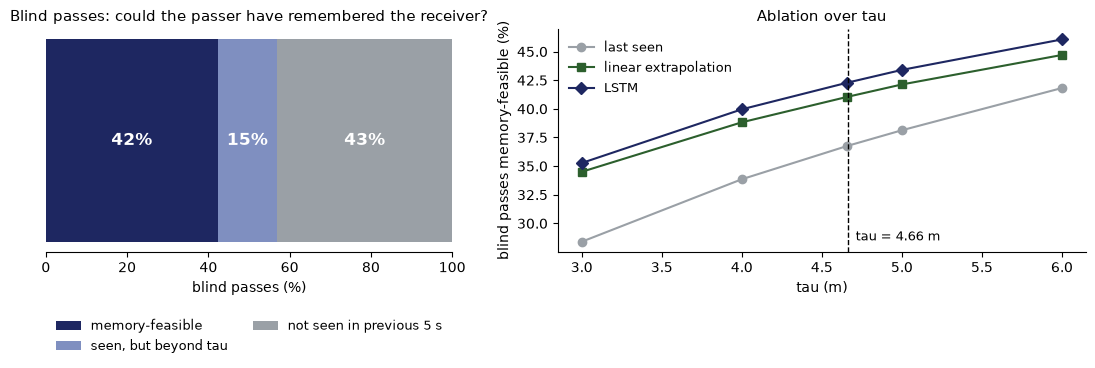

In [5]:
NAVY, GREEN, GREY, LIGHT = '#1E2761', '#2C5F2D', '#9AA0A6', '#7F8FC0'
fig, axes = plt.subplots(1, 2, figsize=(11, 4), gridspec_kw={'width_ratios': [1, 1.3]})

ax = axes[0]
not_seen = 1 - blind['has_memory'].mean()
seen_far = (blind['has_memory'] & ~blind['feasible_lstm']).mean()
feas = blind['feasible_lstm'].mean()
left = 0
for share, colour, label in [(feas, NAVY, 'memory-feasible'), (seen_far, LIGHT, 'seen, but beyond tau'),
                             (not_seen, GREY, 'not seen in previous 5 s')]:
    ax.barh(0, share * 100, left=left, color=colour, label=label)
    ax.text(left + share * 50, 0, f'{share:.0%}', ha='center', va='center', color='white', fontsize=12, fontweight='bold')
    left += share * 100
ax.set_xlim(0, 100)
ax.set_yticks([])
ax.set_xlabel('blind passes (%)')
ax.set_title('Blind passes: could the passer have remembered the receiver?', fontsize=11)
ax.legend(frameon=False, loc='upper center', bbox_to_anchor=(0.5, -0.25), ncol=2, fontsize=9)
ax.spines[['top', 'right', 'left']].set_visible(False)

ax = axes[1]
for name, colour, marker in [('last seen', GREY, 'o'), ('linear extrapolation', GREEN, 's'), ('LSTM', NAVY, 'D')]:
    ax.plot(ablation.index, ablation[name] * 100, marker=marker, color=colour, label=name)
ax.axvline(TAU, color='black', ls='--', lw=1)
ax.text(TAU + 0.05, ax.get_ylim()[0] + 1, f'tau = {TAU:.2f} m', fontsize=9)
ax.set_xlabel('tau (m)')
ax.set_ylabel('blind passes memory-feasible (%)')
ax.set_title('Ablation over tau', fontsize=11)
ax.legend(frameon=False, fontsize=9)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
save_fig(plt.gcf(), 'rq3_pff_headline.png')
plt.show()

## 5. Comparison with the StatsBomb version of RQ3

The StatsBomb figures are from `05_layer3_lstm_training.ipynb` and `06_layer3_blind_passes.ipynb`. The two versions differ in what "memory" means:

- **StatsBomb:** a teammate was on camera in the last 2 s, so this is an upper bound on what the passer could know.
- **PFF:** a teammate was inside the passer's own cone in the last 5 s.

The two versions also use different data (166 matches of freeze frames against 64 games of tracking). So the comparison is about whether the conclusions agree, not about matching numbers.

In [6]:
lo_c, hi_c = paired_game_ci(cmp, 'feasible', 'exp_feasible')
comparison = pd.DataFrame({
    'StatsBomb 360': {
        'receivers inside the cone vs expected': '52.3% vs 34.5%',
        'blind passes (share of passes with a receiver)': '47.7%',
        'memory definition': 'on camera in last 2 s',
        'LSTM error vs last position (m)': '3.05 vs 3.16',
        'tau (m)': '4.0 (proposal range)',
        'receiver memory-feasible vs other unseen': '42.1% vs 44.4% (-2.3)',
    },
    'PFF tracking': {
        'receivers inside the cone vs expected': '59.2% vs 33.2% (part 1)',
        'blind passes (share of passes with a receiver)': '40.8% (part 1)',
        'memory definition': "inside the passer's cone in last 5 s",
        'LSTM error vs last position (m)': f"{mates.loc[mates['target_visible'], 'err_lstm'].mean():.2f} vs "
                                           f"{mates.loc[mates['target_visible'], 'err_last'].mean():.2f}",
        'tau (m)': f'{TAU:.2f} (half the median back-line gap)',
        'receiver memory-feasible vs other unseen': f"{cmp['feasible'].mean():.1%} vs {cmp['exp_feasible'].mean():.1%} "
                                                     f"({100 * (cmp['feasible'].mean() - cmp['exp_feasible'].mean()):+.1f}, "
                                                     f"CI {100 * lo_c:+.1f} to {100 * hi_c:+.1f})",
    }})
print(comparison.to_string())

                                                        StatsBomb 360                            PFF tracking
receivers inside the cone vs expected                  52.3% vs 34.5%                 59.2% vs 33.2% (part 1)
blind passes (share of passes with a receiver)                  47.7%                          40.8% (part 1)
memory definition                               on camera in last 2 s    inside the passer's cone in last 5 s
LSTM error vs last position (m)                          3.05 vs 3.16                            3.03 vs 4.06
tau (m)                                          4.0 (proposal range)    4.66 (half the median back-line gap)
receiver memory-feasible vs other unseen        42.1% vs 44.4% (-2.3)  42.1% vs 39.1% (+3.0, CI +2.2 to +3.8)


**What this shows**

**The two versions agree on the vision cone, the LSTM and the scale of memory.**

- **The vision cone:** receivers are inside the cone far more often than chance in both versions (+17.8 points with StatsBomb, +26.0 with PFF).
- **The LSTM:** it reaches about 3 m in both. With PFF it beats last seen by 1 m rather than 0.1 m, because the history is continuous and correctly identified rather than linked freeze frames.
- **tau:** the PFF tau of 4.66 m, measured from defensive line widths, confirms the 4 m chosen from the proposal's range for the StatsBomb version.

**They disagree on whether blind passes favour remembered teammates.** StatsBomb finds -2.3 points; PFF finds +3.0 points. The PFF version is the stronger test: it defines memory as what the passer actually had in view rather than what was on camera, uses continuous tracking with real player identities, and scores only against positions tracked on camera. Its result is the one used to answer RQ3.

## 6. Save

In [7]:
blind.to_pickle(RESULTS / 'rq3_pff_blind_passes.pkl')
check.to_pickle(RESULTS / 'rq3_pff_arrival.pkl')
ablation.to_pickle(RESULTS / 'rq3_pff_tau_ablation.pkl')
print('saved rq3_pff_blind_passes.pkl, rq3_pff_arrival.pkl, rq3_pff_tau_ablation.pkl')

saved rq3_pff_blind_passes.pkl, rq3_pff_arrival.pkl, rq3_pff_tau_ablation.pkl


## Summary: the answer to RQ3

**RQ3** asks whether blind passes can be explained by the passer's spatial memory of teammates outside their vision cone.

**Blind passes are common.** 40.8 percent of completed passes go to a receiver outside the passer's 120 degree cone (part 1).

**The memory model works.** The LSTM places unseen teammates with a mean error of 3.03 m from what the passer saw in the previous 5 s, better than last seen (4.06 m) and linear extrapolation (3.79 m) in all 64 games (part 2). This meets H3's 3 to 5 m threshold.

**About four in ten blind passes are memory-feasible.** 42.3 percent (95 percent CI 41.5 to 43.0) went to a receiver the passer could have located within tau = 4.66 m. The share is 35.3 to 46.1 percent for tau from 3 to 6 m. The remaining blind passes went to receivers the passer had not seen in the previous 5 s (43.1 percent), or had seen but could not have placed accurately.

**Passers favour teammates they have seen.** Compared with the other unseen teammates on the same pass, blind-pass receivers were more often seen in the previous 5 s (+6.0 points) and more often memory-feasible (+3.0 points). Both effects are modest but clearly above zero.

**Memory-feasible passes would work.** A pass aimed at the remembered position of a memory-feasible receiver would arrive 88 percent as often as one aimed at their true position. Beyond tau it is only 24 percent as often.

**Answer.** H3 is supported in part. Spatial memory can account for about four in ten blind passes, and passers lean toward teammates they have recently seen. But most blind passes cannot be explained by short-term memory of what was in the passer's cone. These may rely on things this data cannot measure: glances over the shoulder (the cone follows movement, not head direction), calls from teammates, or tactical knowledge of where a teammate is likely to be.

Saved: `rq3_pff_blind_passes.pkl`, `rq3_pff_arrival.pkl`, `rq3_pff_tau_ablation.pkl` and `figures/rq3_pff_headline.png`.